/home/students/s328743/.conda/envs/bertopic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


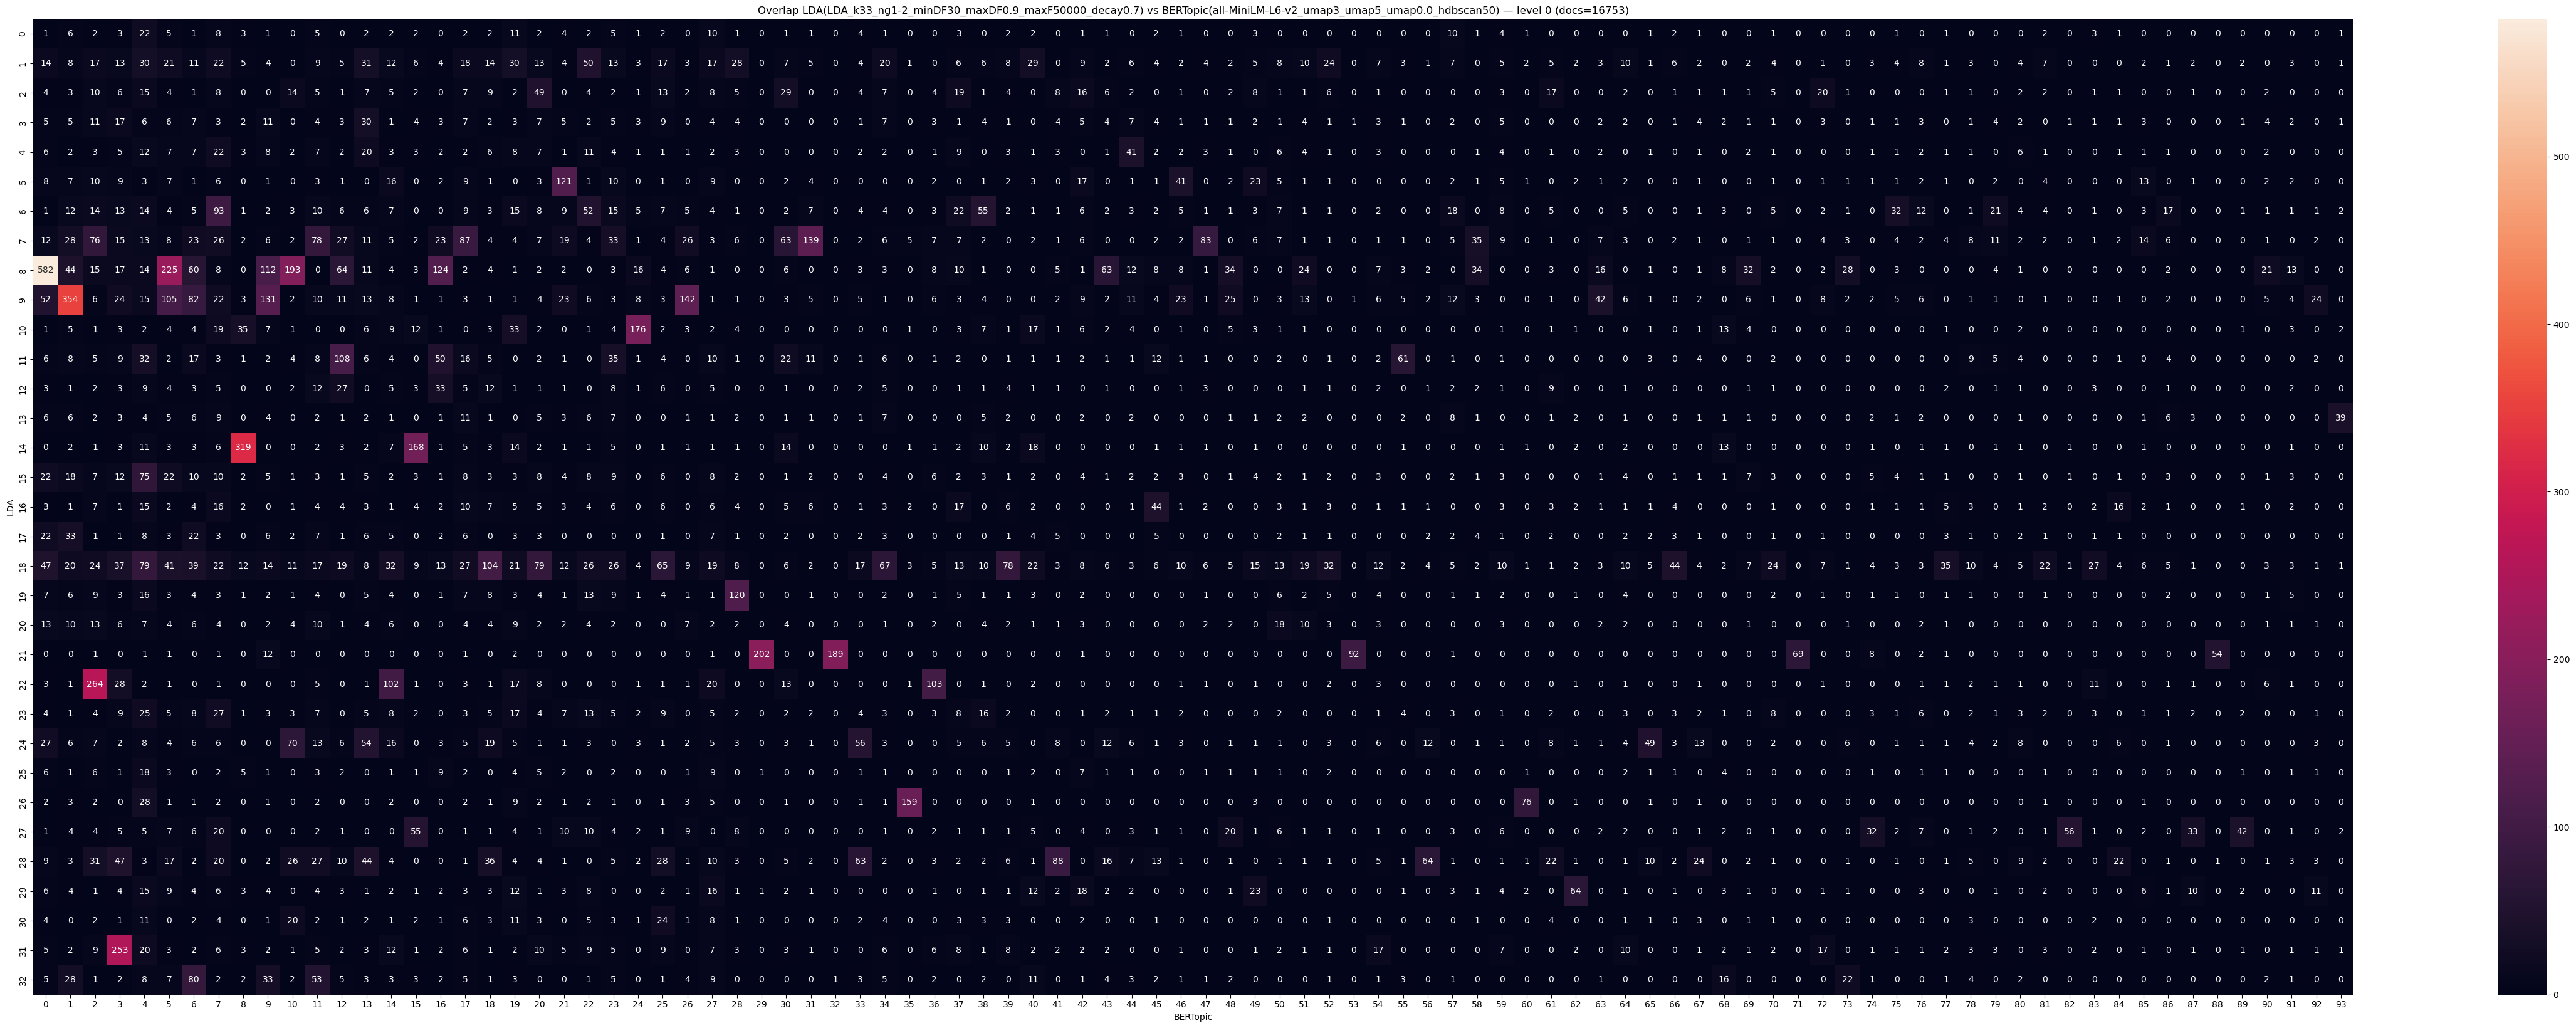

In [1]:
# Overlap LDA vs BERTopic — config una sola volta (LEVEL, LDA_NAME, BERT_NAME)
import os, joblib, numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from bertopic import BERTopic

# ====== CONFIG (modifica SOLO queste 3 variabili) ======
LEVEL = "0"
LDA_NAME  = "LDA_k33_ng1-2_minDF30_maxDF0.9_maxF50000_decay0.7"
BERT_NAME = "all-MiniLM-L6-v2_umap3_umap5_umap0.0_hdbscan50"
INCLUDE_OUTLIERS = False

# ====== BASE PATH (non toccare, salvo esigenze) ======
ROOT = "/home/students/s328743/Thesis/Smart_crawler_telegram/results/levels"

# ====== PATH DERIVATI ======
# LDA
base_lda = f"{ROOT}/level_{LEVEL}/grid_search_lda"
lda_model_path      = f"{base_lda}/lda_models_level_{LEVEL}/{LDA_NAME}.joblib"
lda_vectorizer_path = f"{base_lda}/vectorizers_level_{LEVEL}/vectorizer_{LDA_NAME}.joblib"
lda_docs_csv        = f"{base_lda}/df_sampled_level_{LEVEL}.csv"

# BERTopic
base_bert = f"{ROOT}/level_{LEVEL}/grid_search"
bert_model_path = f"{base_bert}/bertopic_models_level_{LEVEL}/{BERT_NAME}"
bert_docs_csv   = f"{base_bert}/df_sampled_level_{LEVEL}.csv"

# ====== CARICAMENTO ======
lda_model  = joblib.load(lda_model_path)
vectorizer = joblib.load(lda_vectorizer_path)
topic_model = BERTopic.load(bert_model_path)

df_lda  = pd.read_csv(lda_docs_csv)
df_bert = pd.read_csv(bert_docs_csv)

# ====== ASSEGNAZIONI TOPIC ======
X = vectorizer.transform(df_lda["text_preprocessed"].astype(str).tolist())
lda_labels  = lda_model.transform(X).argmax(axis=1)
bert_labels = np.asarray(topic_model.topics_, dtype=int)     # -1 = outlier

# ====== OVERLAP & HEATMAP ======
merged = (
    pd.DataFrame({"text_preprocessed": df_lda["text_preprocessed"].astype(str), "LDA": lda_labels})
    .merge(pd.DataFrame({"text_preprocessed": df_bert["text_preprocessed"].astype(str), "BERT": bert_labels}),
           on="text_preprocessed", how="inner")
)

if not INCLUDE_OUTLIERS:
    merged = merged[merged["BERT"] != -1]

tab = pd.crosstab(merged["LDA"], merged["BERT"], rownames=["LDA"], colnames=["BERTopic"], dropna=False)

plt.figure(figsize=(max(6, tab.shape[1]*0.5), max(4, tab.shape[0]*0.5)))
ax = sns.heatmap(tab, annot=True, fmt="d")
ax.set_title(f"Overlap LDA({LDA_NAME}) vs BERTopic({BERT_NAME}) — level {LEVEL} (docs={len(merged)})")
plt.tight_layout()

# opzionale: salvataggi
out_prefix = f"overlap_level_{LEVEL}"
tab.to_csv(f"{out_prefix}_matrix.csv", index=True)
plt.savefig(f"{out_prefix}_heatmap.png", dpi=150)
plt.show()


In [4]:
sum_by_row=tab.sum(axis=1)
sum_by_column=tab.sum(axis=0)

sum_by_column

BERTopic
0     887
1     632
2     568
3     555
4     546
     ... 
89     54
90     53
91     53
92     51
93     50
Length: 94, dtype: int64

In [10]:
tab_normalized_by_row_sum=tab.divide(sum_by_row,axis=0)
tab_normalized_by_column_sum=tab.divide(sum_by_column,axis=1)

BERTopic
0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
     ... 
89    1.0
90    1.0
91    1.0
92    1.0
93    1.0
Length: 94, dtype: float64

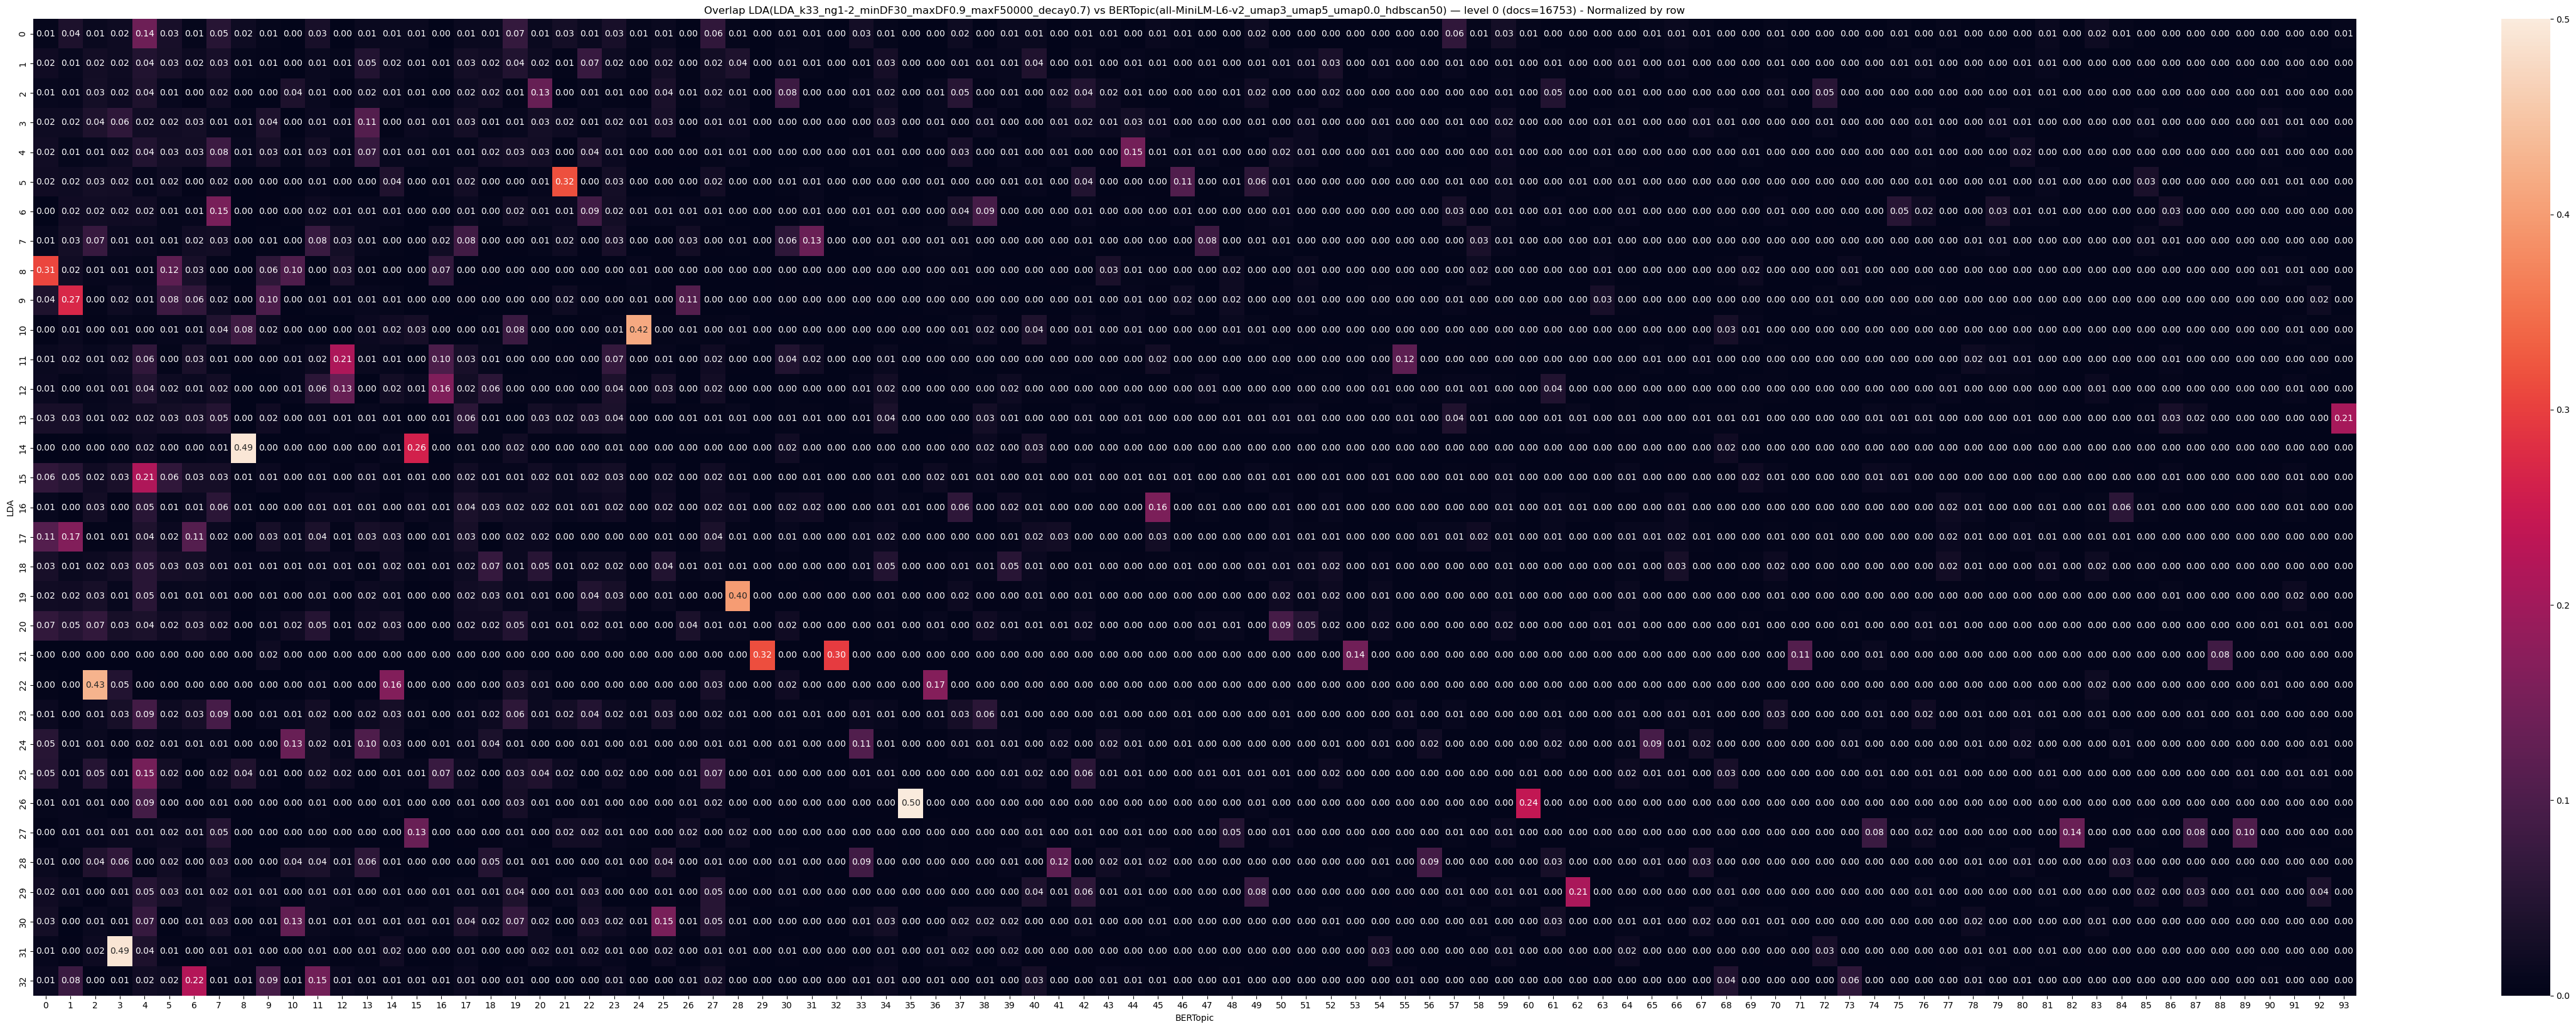

In [13]:
plt.figure(figsize=(max(6, tab.shape[1]*0.5), max(4, tab.shape[0]*0.5)))
ax = sns.heatmap(tab_normalized_by_row_sum, annot=True, fmt=".2f")
ax.set_title(f"Overlap LDA({LDA_NAME}) vs BERTopic({BERT_NAME}) — level {LEVEL} (docs={len(merged)}) - Normalized by row")
plt.tight_layout()

# opzionale: salvataggi
out_prefix = f"overlap_level_{LEVEL}"
tab_normalized_by_row_sum.to_csv(f"{out_prefix}_matrix_normalized_by_row.csv", index=True)
plt.savefig(f"{out_prefix}_normalized_by_row.png", dpi=150)
plt.show()

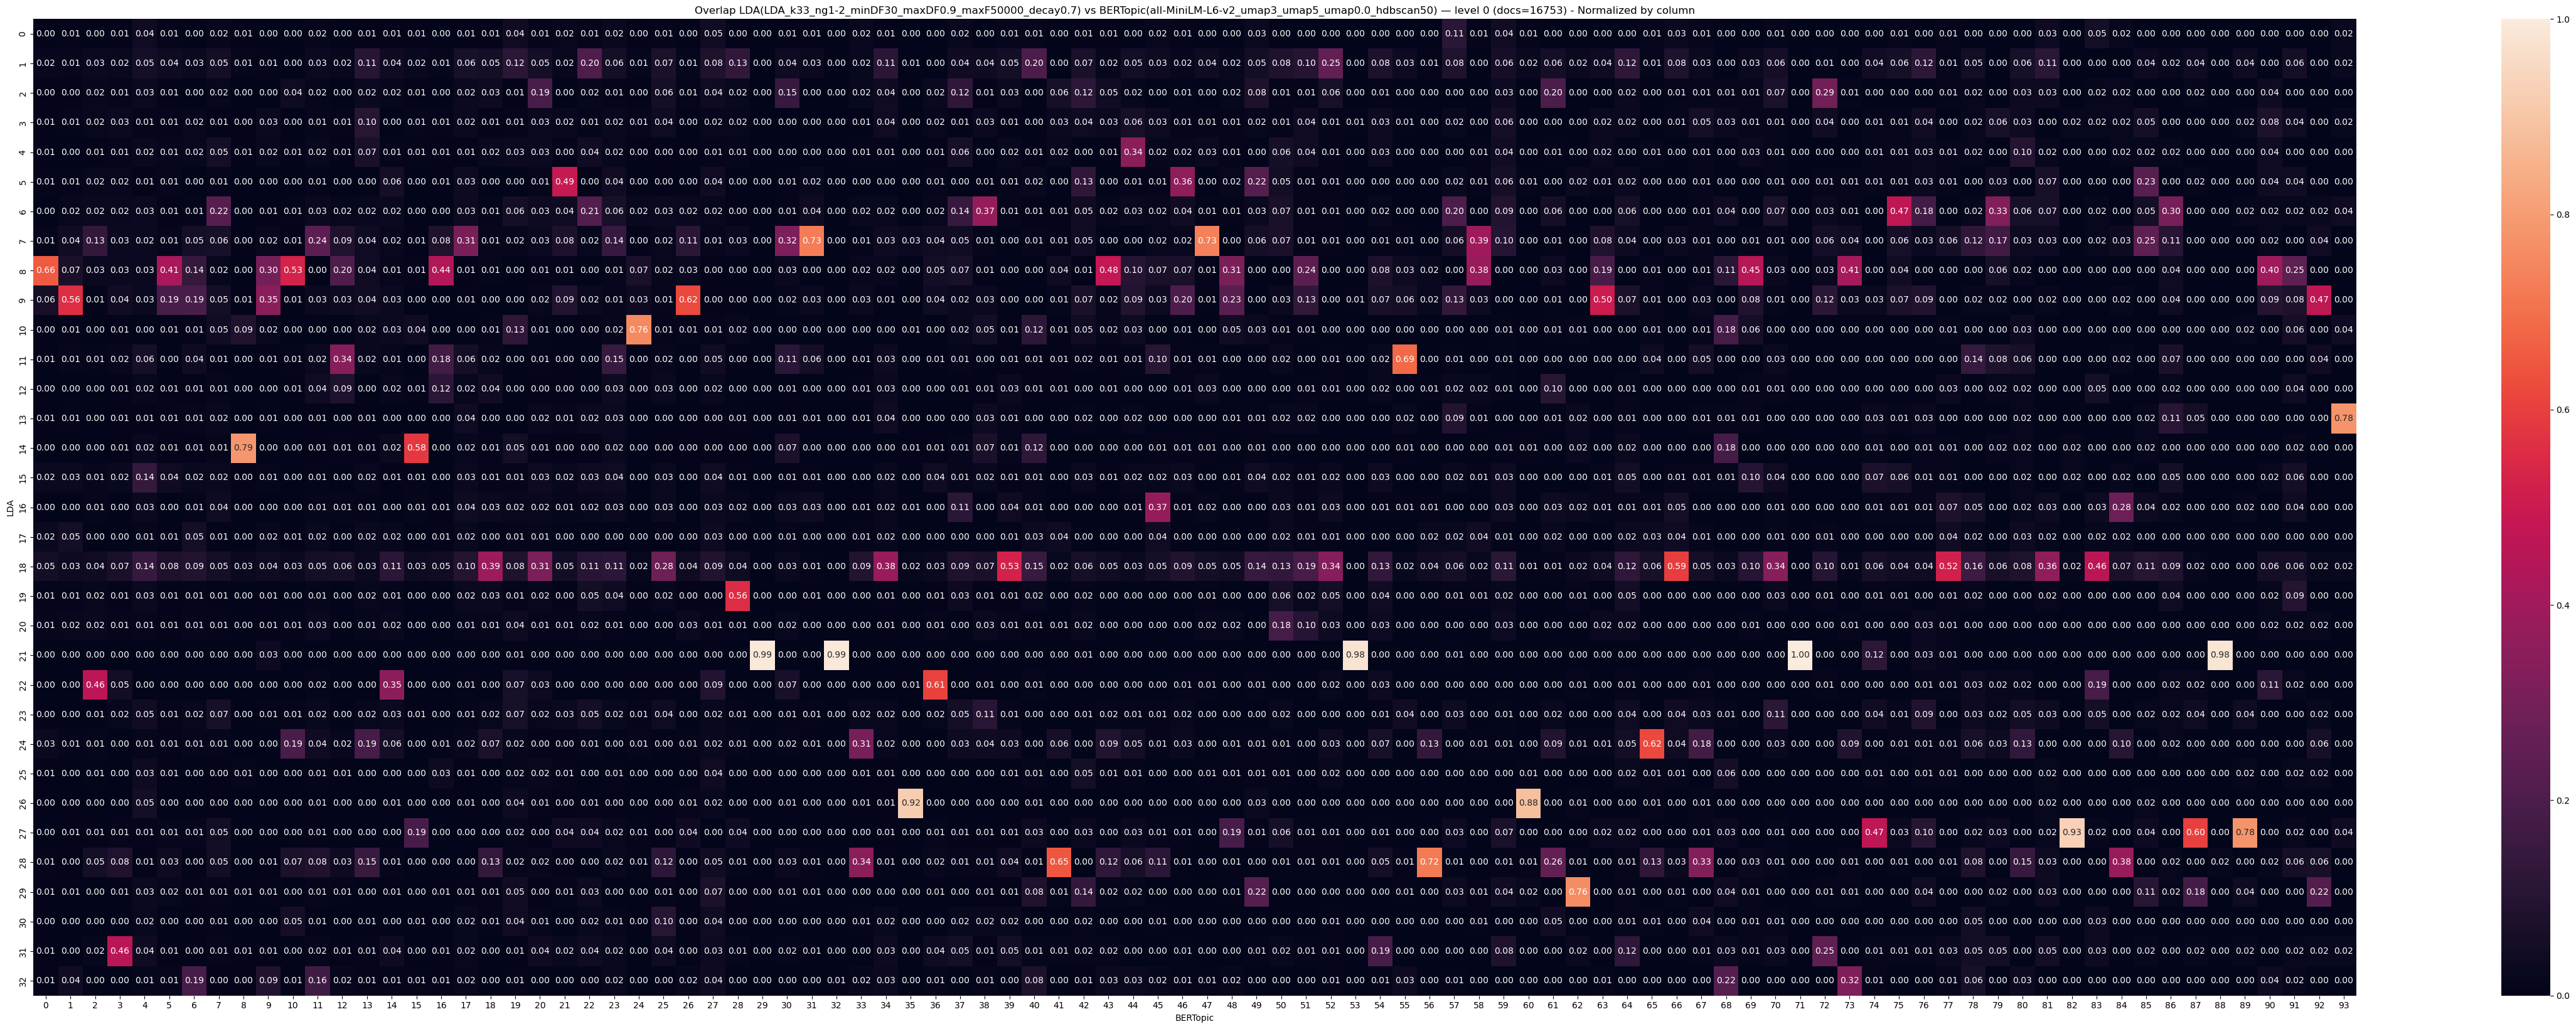

In [14]:
plt.figure(figsize=(max(6, tab.shape[1]*0.5), max(4, tab.shape[0]*0.5)))
ax = sns.heatmap(tab_normalized_by_column_sum, annot=True, fmt=".2f")
ax.set_title(f"Overlap LDA({LDA_NAME}) vs BERTopic({BERT_NAME}) — level {LEVEL} (docs={len(merged)}) - Normalized by column")
plt.tight_layout()

# opzionale: salvataggi
out_prefix = f"overlap_level_{LEVEL}"
tab_normalized_by_column_sum.to_csv(f"{out_prefix}_matrix_normalized_by_column.csv", index=True)
plt.savefig(f"{out_prefix}_normalized_by_column.png", dpi=150)
plt.show()

In [15]:
merged

,text_preprocessed,LDA,BERT
1,america greater support join share join storm,27,74
2,vance number high millions illegals come kamal...,25,16
3,japanese scientists find indisputable evidence...,6,7
6,world wrought evil deception lies need decernm...,1,22
7,qanon tier covid tier boomer bullshit,27,52
...,...,...,...
30046,took bullet room watching stood said fight pre...,9,63
30048,trump killing elon musk right momentum,5,46
30049,believe religion politics aren connected under...,18,4
30051,public school employee arrested beating disabl...,7,31


In [17]:
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import adjusted_rand_score

print(adjusted_mutual_info_score(merged['LDA'],merged['BERT']),adjusted_rand_score(merged['LDA'],merged['BERT']))


0.2922716343148605 0.12810797030854223
